# Simple galaxy classification model 

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score,confusion_matrix
import seaborn as sns

In this mini-project, we aim to build a supervised classification model using a Random Forest classifier. Our goal is to classify galaxies as either central or satellite within their respective dark matter halos.

A halo is the region surrounding a galaxy’s visible parts, primarily composed of dark matter. Galaxies form within these dark matter halos. Central galaxies typically reside at the center of the halo, while satellite galaxies orbit around the central galaxy. In this project, we will use the properties of galaxies and their halos to train a model that can distinguish between central and satellite galaxies.

In [2]:

path='22393.csv.bz2'
df=pd.read_csv(path,compression='bz2',header=10)  # Column starts at line 10 rest not needed

In [3]:
df.head()

,unique_halo_id,z_cgal,flag_central,lmhalo,gr_gal,lsfr,metallicity,lml_r,lmstellar
0,211412867,1.01901,0,11.2311,0.3215,-0.036,9.113,-0.240,8.935
1,315524816,0.44484,0,10.7868,0.8521,-0.932,8.312,0.057,8.455
2,312596881,0.28544,0,10.6506,0.4458,-1.281,8.304,-0.104,8.028
3,309925768,0.41121,1,10.9239,0.8137,-1.003,8.755,0.119,8.680
4,3663710,0.22479,1,13.9589,0.6660,-1.401,8.384,0.291,8.705


Check for null values

In [4]:
df = df.apply(pd.to_numeric, errors='coerce')
df1=df.isnull().sum()
df1

unique_halo_id    0
z_cgal            0
flag_central      0
lmhalo            0
gr_gal            0
lsfr              0
metallicity       0
lml_r             0
lmstellar         0
dtype: int64

In [5]:
df['unique_halo_id'].value_counts()

unique_halo_id
23625651     37
3166978      34
125026       34
489625       29
3397817      28
             ..
12101710      1
11605232      1
52721643      1
52722318      1
129239690     1
Name: count, Length: 1920758, dtype: int64

As we can see big halos have a large amount of galaxies. We will take this into account when performing the train test split.

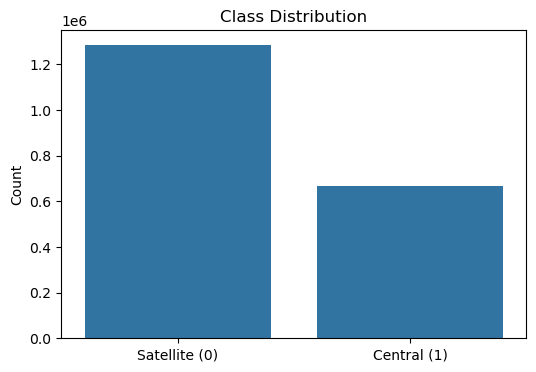

Satellite: 1,285,477  |  Central: 666,337  |  Ratio: 1.9:1


In [6]:
counts = df['flag_central'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=['Satellite (0)', 'Central (1)'], y=counts.values)
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()
print(f"Satellite: {counts[0]:,}  |  Central: {counts[1]:,}  |  Ratio: {counts[0]/counts[1]:.1f}:1")

Tried to take out redundant features like absolute magnitude, aparent magnitude , color filters and some features that has low importance (with prior knowledge) about our model like galaxies velocities, peculiar velocities,etc. Tried to compact into the most fundamental features.
-z_cgal: redshift
-metallicity: metallicity in units 12+logO/H
-Imhalo: log base 10 of FoF halo mass
-lml_r: logarithm of the stellar_mas/luminosity ratio in the r SDSS band
-lsfr: ogarithm of star formation rate in (Msolar/h)/year
-gr_gal: (g-r) rest-frame at z=0 without evolutionary correction(color in the g-r band)


Before splitting the data into training and test sets, it is important to consider that galaxies belonging to the same halo share certain properties. If galaxies from the same halo appear in both the training and test sets, the model may overfit, learning halo-specific features rather than general patterns.

To prevent this, we ensure that all galaxies from a given halo are assigned to the same set. In other words, galaxies in the training set and test set come from different halos, so the model is tested on halos it has never seen before.

In [7]:
features = ['z_cgal', 'lmhalo','gr_gal', 'lsfr', 'metallicity', 'lml_r', 'lmstellar']
target = 'flag_central'

# Split halo IDs
halo_ids = df['unique_halo_id'].unique()
train_halos, test_halos = train_test_split(halo_ids, test_size=0.2, random_state=42)

# Assign galaxies to train/test based on halo
train_df = df[df['unique_halo_id'].isin(train_halos)]
test_df  = df[df['unique_halo_id'].isin(test_halos)]

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]


In [8]:
sample_size=100000
X_train_sub = X_train.sample(n=sample_size, random_state=42)
y_train_sub = y_train.loc[X_train_sub.index]

In [9]:
rf = RandomForestClassifier(
    n_jobs=1,
    random_state=42,
    class_weight='balanced'   # handles class imbalance
)

# 2. Define hyperparameter search space
param_dist = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2', 0.8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# 3. RandomizedSearchCV setup
rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,             # number of random combinations to try
    cv=3,                  # 3-fold cross-validation
    scoring='roc_auc',     # better than accuracy for imbalance
    verbose=2,
    random_state=42,
    n_jobs=1
)

# 4. Fit on TRAIN set
rs.fit(X_train_sub, y_train_sub)

# 5. Best parameters
print("Best hyperparameters:", rs.best_params_)

# 6. Evaluate on TEST set
y_pred = rs.predict(X_test)
y_prob = rs.predict_proba(X_test)[:, 1]

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=10, min_samples_split=5, n_estimators=100; total time=  28.4s
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=10, min_samples_split=5, n_estimators=100; total time=  28.1s
[CV] END max_depth=30, max_features=0.8, min_samples_leaf=10, min_samples_split=5, n_estimators=100; total time=  28.5s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=700; total time= 4.0min
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=700; total time= 4.1min
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=700; total time= 3.9min
[CV] END max_depth=10, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  25.0s
[CV] END max_depth=10, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=10

To find the best hyperparameters for our model, we used RandomizedSearchCV. Since our dataset is very large, testing every possible combination of hyperparameters (as in a full grid search) would be computationally impossible.

RandomizedSearchCV solves this by sampling a fixed number of random hyperparameter combinations, which significantly reduces computation time. However, due to the size of our dataset, we still needed to use a subsample to make the computation manageable since our dataset has around 4 million galaxies.

I took the 100000 samples computation.(it takes a lot around 30 min). you can get reasonable results with 1000 and 10000 samples as well.

For scoring, we chose ROC AUC, a performance metric that measures the model’s ability to distinguish between classes. It is especially useful when the classes are highly imbalanced. We used ROC AUC to select the best-performing model and to guide hyperparameter tuning.



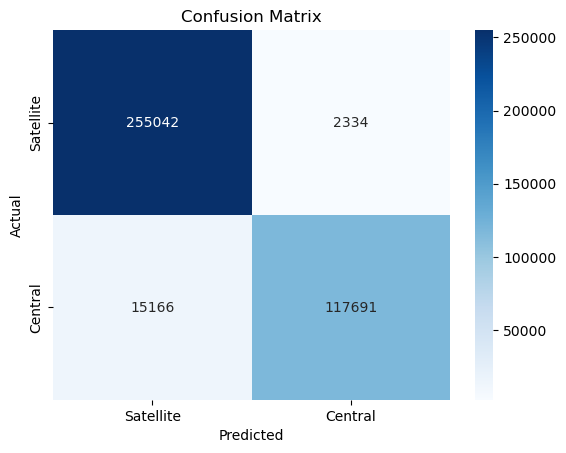

In [18]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Satellite', 'Central'],
            yticklabels=['Satellite', 'Central'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Our classification model shows a good result and strong performance. For the central class (0) the model achieve a precision of 0.94 and recall of 0.99. For the satelite class the precision is 0.98 and the recall 0.89 which shows how robut is our model. Our ROC AUC metric is giving us 0.98 which tell us that our algoritm separation classes is excellent. 

The lower recall for satellite galaxies indicates that the model more often misclassifies actual satellites as central galaxies. We can see this on the confusion matrix.



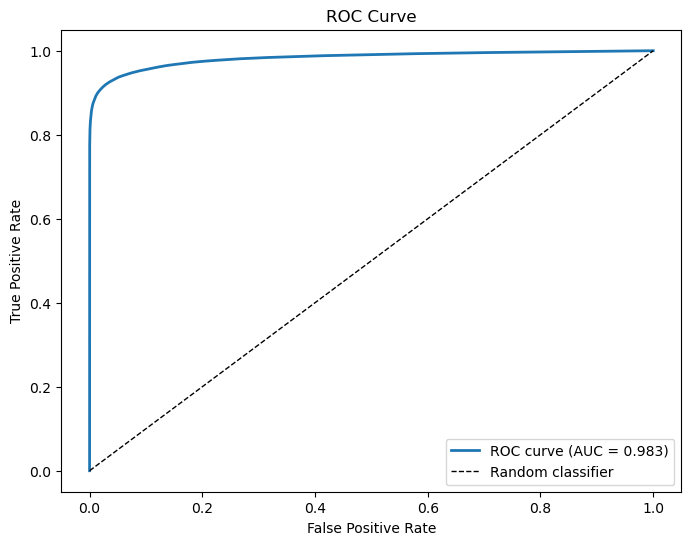

In [15]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [16]:
importances = rs.best_estimator_.feature_importances_
importances

array([0.03208252, 0.48205583, 0.08688013, 0.04618665, 0.03535272,
       0.09681551, 0.22062664])

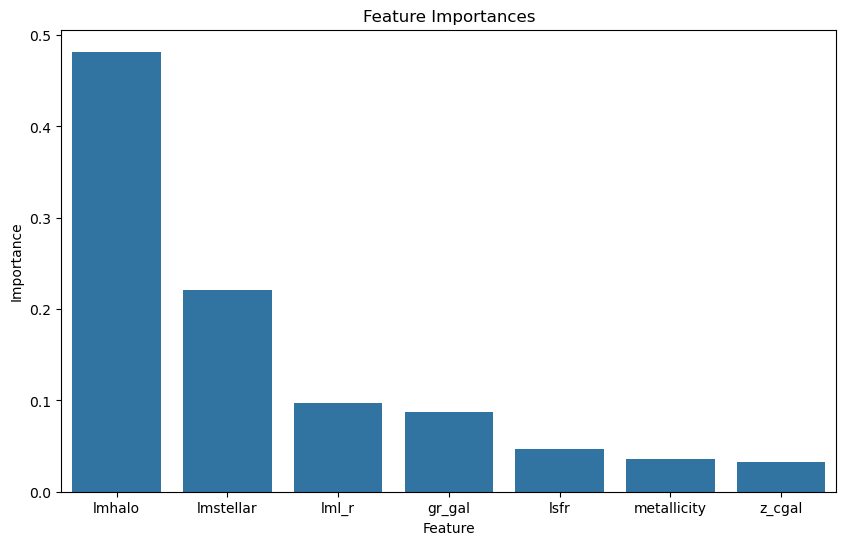

In [17]:
features_importances = pd.DataFrame({'feature': features, 'importances': importances})
features_importances = features_importances.sort_values('importances', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=features_importances, x='feature', y='importances')
plt.title('Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.show()

The most important feature is the mass of the halo in which the galaxy resides. This makes sense, as a more massive halo can host more satellite galaxies, which explains why its importance is approximately 0.5. The next most important feature for classification is the mass of the galaxy itself; more massive galaxies tend to occupy the center of the halo. Other features, such as color or the mass-to-light ratio, have lower importance, around 0.1. Finally, some features, like redshift, metallicity, and star formation rate, have importance below 0.05, indicating they contribute very little to the classification, so the result without them would be valid as well.

A potential future improvement would be to run the model on the full dataset of around 2 million galaxies and to explore adding more features that could help reduce the misclassification of satellite galaxies as central ones. Nothing


